# Linear vs Quadratic Interpolation for a 2:1 FMR Wave

This experiment evolves the same Gaussian-windowed right-moving $E_y/B_z$ wave twice on one fixed root grid with one fixed 2:1 fine patch. The only physics-setting change is the coarse-to-fine interpolation order: linear (`interpolation_order=1`) or quadratic (`interpolation_order=2`).

The numerical $E_y$ field is compared with the continuum wave at every native Yee location. Covered root cells are excluded from the composite error and replaced by native fine cells. A shared-scale, side-by-side movie shows how the signed error propagates before, during, and after the fine-to-coarse interface crossing.

In [1]:
from __future__ import annotations

from io import BytesIO
from pathlib import Path
from tempfile import TemporaryDirectory

import jax
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, Image, Markdown, display
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle


def find_repo_root():
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "PyPIC3D").is_dir() and (candidate / "test_notebooks").is_dir():
            return candidate
    raise RuntimeError("Run this notebook from the PyPIC3D FMR_DEV checkout.")


REPO_ROOT = find_repo_root()

import sys

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from PyPIC3D.initialization import initialize_simulation
from PyPIC3D.solvers.yee.fmr import (
    B_FIELD_LOCATIONS,
    E_FIELD_LOCATIONS,
    prolong_e_to_fine_interface,
)

jax.config.update("jax_enable_x64", True)
mpl.rcParams["animation.embed_limit"] = 100.0

print(f"Repository: {REPO_ROOT}")
print(f"JAX devices: {jax.devices()}")

Repository: /home/christopherwoolford/Documents/Research/projects/PyPIC3D/scratch/FMR_DEV
JAX devices: [CpuDevice(id=0)]


## Fixed physical and numerical problem

Both runs use a $128\times6\times6$ root mesh and one interior patch spanning coarse indices `[32:80, 1:5, 1:5]`. The refinement ratio is fixed at 2, giving root/fine spacings of 1 and 0.5. The timestep, frame times, wave profile, and analytical subtraction are identical.

In [2]:
INTERPOLATION_ORDERS = (1, 2)
INTERPOLATION_LABELS = {1: "Linear", 2: "Quadratic"}
REFINEMENT_RATIO = 2
ROOT_SHAPE = np.asarray((128, 6, 6), dtype=int)
PATCH_START = np.asarray((32, 1, 1), dtype=int)
PATCH_STOP = np.asarray((80, 5, 5), dtype=int)
GUARD_CELLS = 2

DOMAIN_MIN = np.asarray((0.0, 0.0, 0.0))
DOMAIN_MAX = np.asarray((128.0, 6.0, 6.0))
PATCH_MIN = np.asarray((32.0, 1.0, 1.0))
PATCH_MAX = np.asarray((80.0, 5.0, 5.0))

WAVE_AMPLITUDE = 1.0
PULSE_CENTER = 56.0
PULSE_WIDTH = 6.0
WAVELENGTH = 16.0
WAVE_NUMBER = 2.0 * np.pi / WAVELENGTH

DT = 0.15
FINAL_TIME = 54.0
FRAME_DT = 0.6
FRAME_TIMES = np.linspace(0.0, FINAL_TIME, int(round(FINAL_TIME / FRAME_DT)) + 1)
NUM_FRAMES = len(FRAME_TIMES)
PLOT_Z = 3.0
INTERFACE_CROSSING_TIME = PATCH_MAX[0] - PULSE_CENTER

assert NUM_FRAMES == 91
assert np.isclose(FRAME_TIMES[-1], FINAL_TIME)
assert np.isclose(INTERFACE_CROSSING_TIME, 24.0)
assert np.max(
    np.abs(np.exp(-0.5 * ((np.asarray((32.0, 80.0)) - PULSE_CENTER) / PULSE_WIDTH) ** 2))
) < 5.0e-4

## Production setup and native Yee initialization

`initialize_simulation` constructs the production FMR maps for the requested interpolation order, and `time_loop_electrodynamic_fmr_fields` advances the fields. Before interface prolongation, the same analytical profile is sampled independently on native root and fine $E_y/B_z$ coordinates. Prolongation then overwrites only the constrained fine-$E$ interface locations.

In [3]:
def fmr_config(interpolation_order, output_dir):
    return {
        "static_parameters": {
            "name": f"2:1 FMR wave, {INTERPOLATION_LABELS[interpolation_order].lower()} interpolation",
            "output_dir": str(output_dir),
            "solver": "electrodynamic_yee",
            "Nt": int(round(FINAL_TIME / DT)),
            "guard_cells": GUARD_CELLS,
            "particle_tile_nx": int(ROOT_SHAPE[0]),
            "particle_tile_ny": int(ROOT_SHAPE[1]),
            "particle_tile_nz": int(ROOT_SHAPE[2]),
            "current_calculation": "j_from_rhov",
            "filter_j": "none",
            "x_bc": "periodic",
            "y_bc": "periodic",
            "z_bc": "periodic",
        },
        "dynamic_parameters": {
            "Nx": int(ROOT_SHAPE[0]),
            "Ny": int(ROOT_SHAPE[1]),
            "Nz": int(ROOT_SHAPE[2]),
            "x_min": DOMAIN_MIN[0],
            "x_max": DOMAIN_MAX[0],
            "y_min": DOMAIN_MIN[1],
            "y_max": DOMAIN_MAX[1],
            "z_min": DOMAIN_MIN[2],
            "z_max": DOMAIN_MAX[2],
            "dt": DT,
            "C": 1.0,
            "eps": 1.0,
            "mu": 1.0,
        },
        "fmr": {
            "enabled": True,
            "interpolation_order": interpolation_order,
            "levels": [{
                "parent": 0,
                "refinement_ratio": REFINEMENT_RATIO,
                "coarse_start": list(PATCH_START),
                "coarse_stop": list(PATCH_STOP),
            }],
        },
    }


def component_axis(grids, locations, axis):
    tiled_grid = grids.tiled_vertex_grid if locations[axis] == "V" else grids.tiled_center_grid
    return tiled_grid[axis][0, 0, 0]


def active_component_axis(level, level_data, locations, axis, guard_cells):
    cells = (level.Nx, level.Ny, level.Nz)[axis]
    axis_values = component_axis(level_data.grids, locations, axis)
    return axis_values[guard_cells:guard_cells + cells]


def wave_profile(x, time=0.0):
    displacement = x - (PULSE_CENTER + time)
    envelope = jnp.exp(-0.5 * (displacement / PULSE_WIDTH) ** 2)
    return WAVE_AMPLITUDE * envelope * jnp.cos(WAVE_NUMBER * displacement)


def initialize_wave(fields, dynamic_parameters):
    E_levels, B_levels, J_levels = fields[:3]
    initialized_E = []
    initialized_B = []

    for E_level, B_level, level_data in zip(
        E_levels, B_levels, dynamic_parameters.fmr.levels
    ):
        x_Ey = component_axis(level_data.grids, E_FIELD_LOCATIONS[1], axis=0)
        x_Bz = component_axis(level_data.grids, B_FIELD_LOCATIONS[2], axis=0)

        Ex, Ey, Ez = E_level
        Bx, By, Bz = B_level
        Ey = jnp.broadcast_to(
            wave_profile(x_Ey)[jnp.newaxis, jnp.newaxis, jnp.newaxis, :, jnp.newaxis, jnp.newaxis],
            Ey.shape,
        )
        Bz = jnp.broadcast_to(
            wave_profile(x_Bz)[jnp.newaxis, jnp.newaxis, jnp.newaxis, :, jnp.newaxis, jnp.newaxis],
            Bz.shape,
        )
        initialized_E.append((Ex, Ey, Ez))
        initialized_B.append((Bx, By, Bz))

    E_levels = tuple(initialized_E)
    B_levels = tuple(initialized_B)
    native_Ey = tuple(level[1] for level in E_levels)
    E_levels = (
        E_levels[0],
        prolong_e_to_fine_interface(
            E_levels[0],
            E_levels[1],
            dynamic_parameters.fmr.levels[1].e_interface_maps,
        ),
    )
    return (E_levels, B_levels, J_levels, *fields[3:]), native_Ey

## JIT-compiled evolution and composite error

A JAX scan advances each case and retains the active three-dimensional $E_y$ arrays at all 91 frame times. Analytical subtraction is performed afterward at matching root and fine Yee coordinates. The composite norm weights each sample by its level volume and never double-counts the covered root region.

In [4]:
def analytic_history(x):
    displacement = x[np.newaxis, :, np.newaxis, np.newaxis] - (
        PULSE_CENTER + FRAME_TIMES[:, np.newaxis, np.newaxis, np.newaxis]
    )
    envelope = np.exp(-0.5 * (displacement / PULSE_WIDTH) ** 2)
    return WAVE_AMPLITUDE * envelope * np.cos(WAVE_NUMBER * displacement)


def composite_l2_history(root_error, fine_error, root_axes, fine_spacing):
    root_x, root_y, root_z = root_axes
    root_inside_patch = (
        (root_x[:, None, None] >= PATCH_MIN[0])
        & (root_x[:, None, None] < PATCH_MAX[0])
        & (root_y[None, :, None] >= PATCH_MIN[1])
        & (root_y[None, :, None] < PATCH_MAX[1])
        & (root_z[None, None, :] >= PATCH_MIN[2])
        & (root_z[None, None, :] < PATCH_MAX[2])
    )
    root_active = ~root_inside_patch
    root_spacing = np.asarray((
        root_x[1] - root_x[0],
        root_y[1] - root_y[0],
        root_z[1] - root_z[0],
    ))
    root_volume = float(np.prod(root_spacing))
    fine_volume = float(np.prod(fine_spacing))
    num_frames = root_error.shape[0]

    squared_error_integral = (
        root_volume * np.sum(root_error[:, root_active] ** 2, axis=1)
        + fine_volume * np.sum(fine_error.reshape(num_frames, -1) ** 2, axis=1)
    )
    composite_volume = (
        root_volume * np.count_nonzero(root_active)
        + fine_volume * fine_error[0].size
    )
    return np.sqrt(squared_error_integral / composite_volume)


def spacetime_rms(l2_history):
    duration = FRAME_TIMES[-1] - FRAME_TIMES[0]
    return float(np.sqrt(np.trapezoid(l2_history**2, FRAME_TIMES) / duration))


def run_case(interpolation_order):
    label = INTERPOLATION_LABELS[interpolation_order]
    with TemporaryDirectory(
        prefix=f"pypic3d_fmr_{label.lower()}_"
    ) as output_dir:
        (
            evolve_loop,
            particles,
            fields,
            static_parameters,
            dynamic_parameters,
            _plotting_parameters,
            _plasma_parameters,
            species_config,
        ) = initialize_simulation(fmr_config(interpolation_order, output_dir))
        assert evolve_loop.__name__ == "time_loop_electrodynamic_fmr_fields"
        assert static_parameters.fmr_interpolation_order == interpolation_order

        fields, native_Ey = initialize_wave(fields, dynamic_parameters)
        steps_per_frame = int(round(FRAME_DT / float(dynamic_parameters.dt)))
        assert np.isclose(steps_per_frame * float(dynamic_parameters.dt), FRAME_DT)

        root_level, fine_level = static_parameters.fmr_levels
        root_data, fine_data = dynamic_parameters.fmr.levels
        g = int(static_parameters.guard_cells)
        active_root = (
            slice(g, g + root_level.Nx),
            slice(g, g + root_level.Ny),
            slice(g, g + root_level.Nz),
        )
        active_fine = (
            slice(g, g + fine_level.Nx),
            slice(g, g + fine_level.Ny),
            slice(g, g + fine_level.Nz),
        )
        root_axes = tuple(
            active_component_axis(root_level, root_data, E_FIELD_LOCATIONS[1], axis, g)
            for axis in range(3)
        )
        fine_axes = tuple(
            active_component_axis(fine_level, fine_data, E_FIELD_LOCATIONS[1], axis, g)
            for axis in range(3)
        )

        def sample_Ey(field_state):
            E_levels = field_state[0]
            return (
                E_levels[0][1][0, 0, 0][active_root],
                E_levels[1][1][0, 0, 0][active_fine],
            )

        initial_Ey = sample_Ey(fields)
        native_initial_Ey = (
            native_Ey[0][0, 0, 0][active_root],
            native_Ey[1][0, 0, 0][active_fine],
        )

        def advance_one_step(field_state):
            _, field_state = evolve_loop(
                particles,
                species_config,
                field_state,
                static_parameters,
                dynamic_parameters,
            )
            return field_state

        def advance_one_frame(field_state, _):
            field_state = jax.lax.fori_loop(
                0,
                steps_per_frame,
                lambda _step, state: advance_one_step(state),
                field_state,
            )
            return field_state, sample_Ey(field_state)

        @jax.jit
        def evolve_and_sample(field_state):
            return jax.lax.scan(
                advance_one_frame,
                field_state,
                xs=None,
                length=NUM_FRAMES - 1,
            )

        _final_fields, histories = evolve_and_sample(fields)
        histories = tuple(
            jnp.concatenate((initial[jnp.newaxis], history), axis=0)
            for initial, history in zip(initial_Ey, histories)
        )
        histories[1].block_until_ready()

        root_Ey, fine_Ey = (
            np.asarray(jax.device_get(history)) for history in histories
        )
        native_initial_Ey = tuple(
            np.asarray(jax.device_get(component)) for component in native_initial_Ey
        )
        root_axes = tuple(np.asarray(jax.device_get(axis)) for axis in root_axes)
        fine_axes = tuple(np.asarray(jax.device_get(axis)) for axis in fine_axes)
        root_error = root_Ey - analytic_history(root_axes[0])
        fine_error = fine_Ey - analytic_history(fine_axes[0])
        fine_spacing = np.asarray(fine_level.spacing, dtype=float)
        l2_error = composite_l2_history(
            root_error, fine_error, root_axes, fine_spacing
        )

        return {
            "interpolation_order": interpolation_order,
            "label": label,
            "refinement_ratio": int(fine_level.refinement_ratio),
            "root_shape": (root_level.Nx, root_level.Ny, root_level.Nz),
            "fine_shape": (fine_level.Nx, fine_level.Ny, fine_level.Nz),
            "root_spacing": np.asarray(root_level.spacing, dtype=float),
            "fine_spacing": fine_spacing,
            "root_bounds": np.asarray((
                root_level.x_min, root_level.x_max,
                root_level.y_min, root_level.y_max,
                root_level.z_min, root_level.z_max,
            )),
            "fine_bounds": np.asarray((
                fine_level.x_min, fine_level.x_max,
                fine_level.y_min, fine_level.y_max,
                fine_level.z_min, fine_level.z_max,
            )),
            "dt": float(dynamic_parameters.dt),
            "times": FRAME_TIMES.copy(),
            "root_axes": root_axes,
            "fine_axes": fine_axes,
            "native_initial_Ey": native_initial_Ey,
            "root_Ey": root_Ey,
            "fine_Ey": fine_Ey,
            "root_error": root_error,
            "fine_error": fine_error,
            "l2_error": l2_error,
            "spacetime_rms": spacetime_rms(l2_error),
        }

## Run the controlled interpolation comparison

The interpolation maps have different static stencil widths, so JAX compiles the two cases separately. The assertions verify that geometry, timestep, coordinates, frame times, and the analytical native-grid initialization are otherwise identical.

In [5]:
results = {}
for interpolation_order in INTERPOLATION_ORDERS:
    label = INTERPOLATION_LABELS[interpolation_order]
    print(f"Running {label.lower()} interpolation...")
    results[interpolation_order] = run_case(interpolation_order)

linear = results[1]
quadratic = results[2]

assert linear["interpolation_order"] == 1
assert quadratic["interpolation_order"] == 2
for key in ("refinement_ratio", "root_shape", "fine_shape", "dt"):
    assert linear[key] == quadratic[key]
for key in ("root_spacing", "fine_spacing", "root_bounds", "fine_bounds", "times"):
    assert np.array_equal(linear[key], quadratic[key])
for linear_axes, quadratic_axes in (
    (linear["root_axes"], quadratic["root_axes"]),
    (linear["fine_axes"], quadratic["fine_axes"]),
):
    for linear_axis, quadratic_axis in zip(linear_axes, quadratic_axes):
        assert np.array_equal(linear_axis, quadratic_axis)
for linear_initial, quadratic_initial in zip(
    linear["native_initial_Ey"], quadratic["native_initial_Ey"]
):
    assert np.array_equal(linear_initial, quadratic_initial)

assert linear["refinement_ratio"] == quadratic["refinement_ratio"] == 2
assert linear["root_shape"] == quadratic["root_shape"] == tuple(ROOT_SHAPE)
assert np.allclose(linear["root_spacing"], (1.0, 1.0, 1.0))
assert np.allclose(linear["fine_spacing"], (0.5, 0.5, 0.5))
assert np.isclose(linear["dt"], DT)

for result in results.values():
    assert result["root_error"].shape[0] == NUM_FRAMES
    assert result["fine_error"].shape[0] == NUM_FRAMES
    assert result["l2_error"].shape == (NUM_FRAMES,)
    assert np.isfinite(result["root_error"]).all()
    assert np.isfinite(result["fine_error"]).all()
    assert np.isfinite(result["l2_error"]).all()
    assert np.isfinite(result["spacetime_rms"])

print("Validated one fixed 2:1 FMR problem with interpolation order as the controlled variable.")

Running linear interpolation...
Initializing Simulation: 2:1 FMR wave, linear interpolation

Using boundary conditions: x: periodic, y: periodic, z: periodic

Using user defined dt: 0.15
Adjusting t_wind to 54.0 based on provided dt and Nt



time window: 54.0 s with 360 time steps of 0.15 s
x window: 128.0 m [0.0, 128.0] with dx: 1.0 m
y window: 6.0 m [-1.1102230246251565e-16, 6.0] with dy: 1.0 m
z window: 6.0 m [-1.1102230246251565e-16, 6.0] with dz: 1.0 m

Skipping single-resolution energy diagnostics for field-only FMR

Relativistic simulation
Using boris particle pusher
Using field-only electrodynamic Yee FMR solver
Using J from rhov current calculation method with filter: none
Using tiled Yee storage with tile shape: (128, 6, 6)
Running quadratic interpolation...
Initializing Simulation: 2:1 FMR wave, quadratic interpolation

Using boundary conditions: x: periodic, y: periodic, z: periodic

Using user defined dt: 0.15
Adjusting t_wind to 54.0 based on provided dt and Nt

time window: 54.0 s with 360 time steps of 0.15 s
x window: 128.0 m [0.0, 128.0] with dx: 1.0 m
y window: 6.0 m [-1.1102230246251565e-16, 6.0] with dy: 1.0 m
z window: 6.0 m [-1.1102230246251565e-16, 6.0] with dz: 1.0 m

Skipping single-resolution en

## Error histories and total movie error

The first panel compares each case with the analytical wave. The second measures the composite $L_2$ distance between the two signed numerical-error fields on their matching grids. The dashed line marks the time when the packet center reaches the right edge of the fine patch.

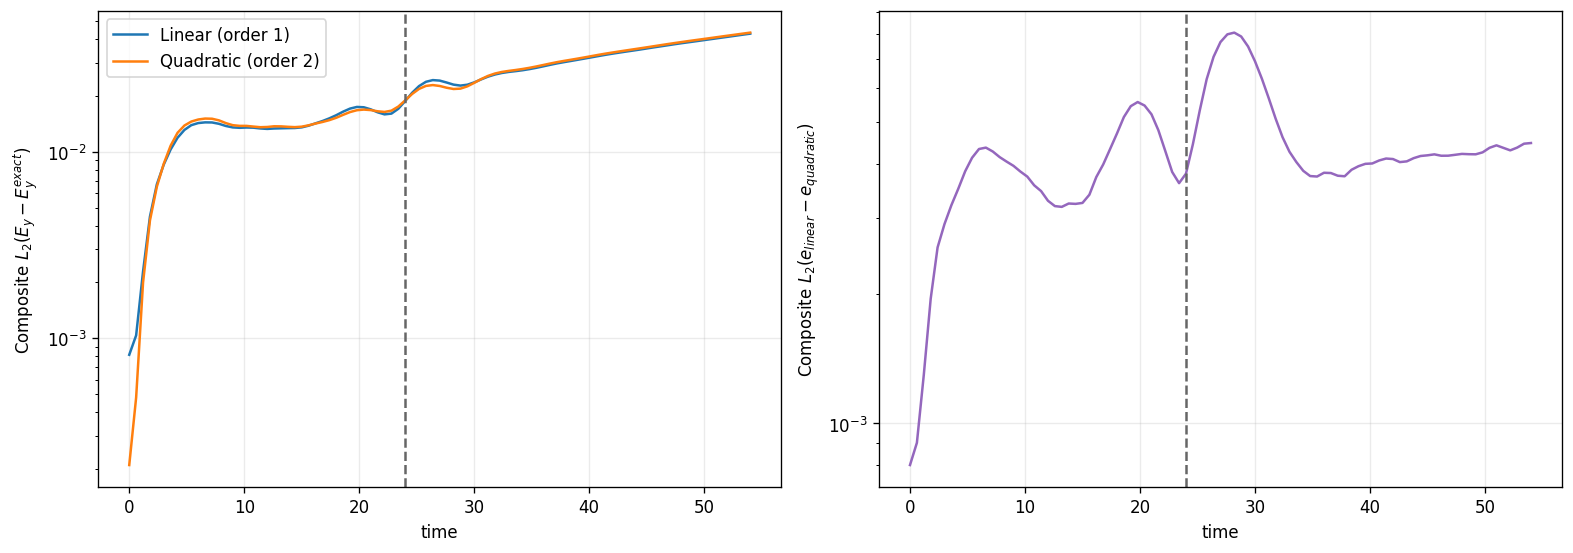

| Interpolation | Initial $L_2$ | Final $L_2$ | Peak $L_2$ | Peak time | Space-time RMS |
|:---|---:|---:|---:|---:|---:|
| Linear (order 1) | 8.145567e-04 | 4.297024e-02 | 4.297024e-02 | 54.0 | 2.556031e-02 |
| Quadratic (order 2) | 2.087195e-04 | 4.352921e-02 | 4.352921e-02 | 54.0 | 2.579000e-02 |

Linear / quadratic space-time RMS error ratio: 0.991094
Space-time RMS difference between interpolation cases: 4.488069e-03


In [6]:
interpolation_difference = composite_l2_history(
    linear["root_error"] - quadratic["root_error"],
    linear["fine_error"] - quadratic["fine_error"],
    linear["root_axes"],
    linear["fine_spacing"],
)
assert np.isfinite(interpolation_difference).all()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for interpolation_order, color in ((1, "tab:blue"), (2, "tab:orange")):
    result = results[interpolation_order]
    axes[0].semilogy(
        FRAME_TIMES,
        result["l2_error"],
        color=color,
        label=f"{result['label']} (order {interpolation_order})",
    )
axes[0].axvline(INTERFACE_CROSSING_TIME, color="0.4", linestyle="--")
axes[0].set_xlabel("time")
axes[0].set_ylabel(r"Composite $L_2(E_y-E_y^{exact})$")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].semilogy(
    FRAME_TIMES,
    np.maximum(interpolation_difference, np.finfo(float).tiny),
    color="tab:purple",
)
axes[1].axvline(INTERFACE_CROSSING_TIME, color="0.4", linestyle="--")
axes[1].set_xlabel("time")
axes[1].set_ylabel(r"Composite $L_2(e_{linear}-e_{quadratic})$")
axes[1].grid(alpha=0.25)

plot_buffer = BytesIO()
fig.savefig(plot_buffer, format="png", dpi=120, bbox_inches="tight")
plt.close(fig)
display(Image(data=plot_buffer.getvalue()))

summary_table = [
    "| Interpolation | Initial $L_2$ | Final $L_2$ | Peak $L_2$ | Peak time | Space-time RMS |",
    "|:---|---:|---:|---:|---:|---:|",
]
for interpolation_order in INTERPOLATION_ORDERS:
    result = results[interpolation_order]
    peak_index = int(np.argmax(result["l2_error"]))
    summary_table.append(
        f"| {result['label']} (order {interpolation_order}) "
        f"| {result['l2_error'][0]:.6e} "
        f"| {result['l2_error'][-1]:.6e} "
        f"| {result['l2_error'][peak_index]:.6e} "
        f"| {FRAME_TIMES[peak_index]:.1f} "
        f"| {result['spacetime_rms']:.6e} |"
    )
display(Markdown("\n".join(summary_table)))

rms_ratio = linear["spacetime_rms"] / quadratic["spacetime_rms"]
difference_total = spacetime_rms(interpolation_difference)
print(f"Linear / quadratic space-time RMS error ratio: {rms_ratio:.6f}")
print(f"Space-time RMS difference between interpolation cases: {difference_total:.6e}")

## Inline side-by-side signed-error movie

Each panel shows the composite $E_y-E_y^{exact}$ plane at $z=3$: root error outside the patch and native fine error inside it. Both interpolation orders share the same axes, synchronized times, and symmetric color scale. The patch boundary is dashed, and each title reports the instantaneous composite error.

In [7]:
def plane_data(result):
    root_x, root_y, root_z = result["root_axes"]
    fine_x, fine_y, fine_z = result["fine_axes"]
    root_z_index = int(np.argmin(np.abs(root_z - PLOT_Z)))
    fine_z_index = int(np.argmin(np.abs(fine_z - PLOT_Z)))
    root_plane = result["root_error"][:, :, :, root_z_index]
    fine_plane = result["fine_error"][:, :, :, fine_z_index]
    root_inside_patch = (
        (root_x[:, None] >= PATCH_MIN[0])
        & (root_x[:, None] < PATCH_MAX[0])
        & (root_y[None, :] >= PATCH_MIN[1])
        & (root_y[None, :] < PATCH_MAX[1])
    )
    visible_root_y = (root_y >= PATCH_MIN[1]) & (root_y < PATCH_MAX[1])
    visible_fine_y = (fine_y >= PATCH_MIN[1]) & (fine_y < PATCH_MAX[1])
    return {
        "root_x": root_x,
        "root_y": root_y,
        "fine_x": fine_x,
        "fine_y": fine_y,
        "root_plane": root_plane,
        "fine_plane": fine_plane,
        "root_inside_patch": root_inside_patch,
        "visible_root_y": visible_root_y,
        "visible_fine_y": visible_fine_y,
    }


movie_data = {
    interpolation_order: plane_data(result)
    for interpolation_order, result in results.items()
}
ERROR_LIMIT = max(
    max(
        float(np.max(np.abs(data["root_plane"][:, :, data["visible_root_y"]]))),
        float(np.max(np.abs(data["fine_plane"][:, :, data["visible_fine_y"]]))),
    )
    for data in movie_data.values()
)
assert ERROR_LIMIT > 0.0

fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharex=True, sharey=True, constrained_layout=True)
meshes = []
titles = []
for ax, interpolation_order in zip(axes, INTERPOLATION_ORDERS):
    result = results[interpolation_order]
    data = movie_data[interpolation_order]
    masked_root = np.ma.masked_where(
        data["root_inside_patch"], data["root_plane"][0]
    ).T
    root_mesh = ax.pcolormesh(
        data["root_x"],
        data["root_y"],
        masked_root,
        shading="nearest",
        cmap="RdBu_r",
        vmin=-ERROR_LIMIT,
        vmax=ERROR_LIMIT,
    )
    fine_mesh = ax.pcolormesh(
        data["fine_x"],
        data["fine_y"],
        data["fine_plane"][0].T,
        shading="nearest",
        cmap="RdBu_r",
        vmin=-ERROR_LIMIT,
        vmax=ERROR_LIMIT,
    )
    ax.add_patch(Rectangle(
        (PATCH_MIN[0], PATCH_MIN[1]),
        PATCH_MAX[0] - PATCH_MIN[0],
        PATCH_MAX[1] - PATCH_MIN[1],
        fill=False,
        edgecolor="black",
        linewidth=1.2,
        linestyle="--",
    ))
    title = ax.set_title(
        f"{result['label']} interpolation (order {interpolation_order})\n"
        f"t={FRAME_TIMES[0]:.1f}, L2={result['l2_error'][0]:.3e}"
    )
    ax.set_xlim(DOMAIN_MIN[0], DOMAIN_MAX[0])
    ax.set_ylim(PATCH_MIN[1], PATCH_MAX[1])
    ax.set_xlabel("x")
    meshes.append((root_mesh, fine_mesh))
    titles.append(title)

axes[0].set_ylabel("y")
colorbar = fig.colorbar(meshes[0][0], ax=axes, pad=0.02)
colorbar.set_label(r"$E_y-E_y^{exact}$")


def update_movie(frame_index):
    artists = []
    for interpolation_order, (root_mesh, fine_mesh), title in zip(
        INTERPOLATION_ORDERS, meshes, titles
    ):
        result = results[interpolation_order]
        data = movie_data[interpolation_order]
        masked_root = np.ma.masked_where(
            data["root_inside_patch"], data["root_plane"][frame_index]
        ).T
        root_mesh.set_array(masked_root.ravel())
        fine_mesh.set_array(data["fine_plane"][frame_index].T.ravel())
        title.set_text(
            f"{result['label']} interpolation (order {interpolation_order})\n"
            f"t={FRAME_TIMES[frame_index]:.1f}, L2={result['l2_error'][frame_index]:.3e}"
        )
        artists.extend((root_mesh, fine_mesh, title))
    return artists


error_movie = FuncAnimation(
    fig, update_movie, frames=NUM_FRAMES, interval=60, blit=False
)
movie_html = error_movie.to_jshtml(default_mode="loop")
plt.close(fig)

assert NUM_FRAMES == len(FRAME_TIMES) == 91
assert "<script" in movie_html and "data:image" in movie_html
print(f"Shared error color range: [{-ERROR_LIMIT:.6e}, {ERROR_LIMIT:.6e}]")
display(HTML(movie_html))

Shared error color range: [-1.465605e+00, 1.465605e+00]


## Interpretation

The packet center reaches the fine-to-coarse interface near $t=24$. Compare the two panels before, during, and after that crossing, using the shared color scale to judge changes in reflected, transmitted, or interface-localized error. The table and difference history quantify what is visible, but no preferred interpolation order or expected reduction is asserted: the measured behavior is retained as the result.